# Dataset description
## Share deaths by gender within age group 2025

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

# Code
## Imports

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Patch, Rectangle

BASE_DIR = Path.cwd().parent.parent

## Load data

In [44]:
logo_path = BASE_DIR / "logo/logo.png"
path = "./data/departamento_muerte.csv"

df = pd.read_csv(path, encoding="utf-8")
logo = plt.imread(logo_path)

## Clean Data

In [45]:
columns = df.columns[
    ~(df.columns.str.contains("Indeterminado")) & 
    ~(df.columns.str.contains("otal")) & 
    ~(df.columns.str.contains("desconocida"))
]

df_f = df.loc[:, columns]

df_f = df_f[
    (df_f["Fecha"].eq(2025)) &
    (df_f["departamento"].eq("Total Nacional"))
]

df_f = df_f.drop(columns=["Fecha", "departamento", "causa"])

columns_male = df_f.columns.str.contains("Hombre")
columns_female = df_f.columns.str.contains("Mujer")

male = df_f.loc[:, columns_male]
female = df_f.loc[:, columns_female]

age_groups = {
    "0-4":   ["Menor 1 hora", "De 1 a 23 horas", "De 1 a 6 días", "De 7 a 27 días",
              "De 28 a 29 días", "De 1 a 5 meses", "De 6 a 11 meses", "De 1 año", "De 2 a 4 años"],
    "5-9":   ["De 5 a 9 años"],
    "10-14": ["De 10 a 14 años"],
    "15-19": ["De 15 a 19 años"],
    "20-24": ["De 20 a 24 años"],
    "25-29": ["De 25 a 29 años"],
    "30-34": ["De 30 a 34 años"],
    "35-39": ["De 35 a 39 años"],
    "40-44": ["De 40 a 44 años"],
    "45-49": ["De 45 a 49 años"],
    "50-54": ["De 50 a 54 años"],
    "55-59": ["De 55 a 59 años"],
    "60-64": ["De 60 a 64 años"],
    "65-69": ["De 65 a 69 años"],
    "70-74": ["De 70 a 74 años"],
    "75-79": ["De 75 a 79 años"],
    "80-84": ["De 80 a 84 años"],
    "85-89": ["De 85 a 89 años"],
    "90-94": ["De 90 a 94 años"],
    "95-99": ["De 95 a 99 años"],
    "100+":  ["De 100 años y más"],
}

def group_by_age(df_gender, suffix, groups):
    result = {}
    for label, prefixes in groups.items():
        cols = [f"{p}_{suffix}" for p in prefixes]
        available = [c for c in cols if c in df_gender.columns]
        result[label] = df_gender[available].sum(axis=1).sum()
    return pd.Series(result, name=suffix)

male_grouped = group_by_age(male, "Hombres", age_groups)
female_grouped = group_by_age(female, "Mujeres", age_groups)

totals = male_grouped + female_grouped
share = pd.DataFrame({
    "Hombres": male_grouped / totals * 100,
    "Mujeres": female_grouped / totals * 100,
})

## Plot

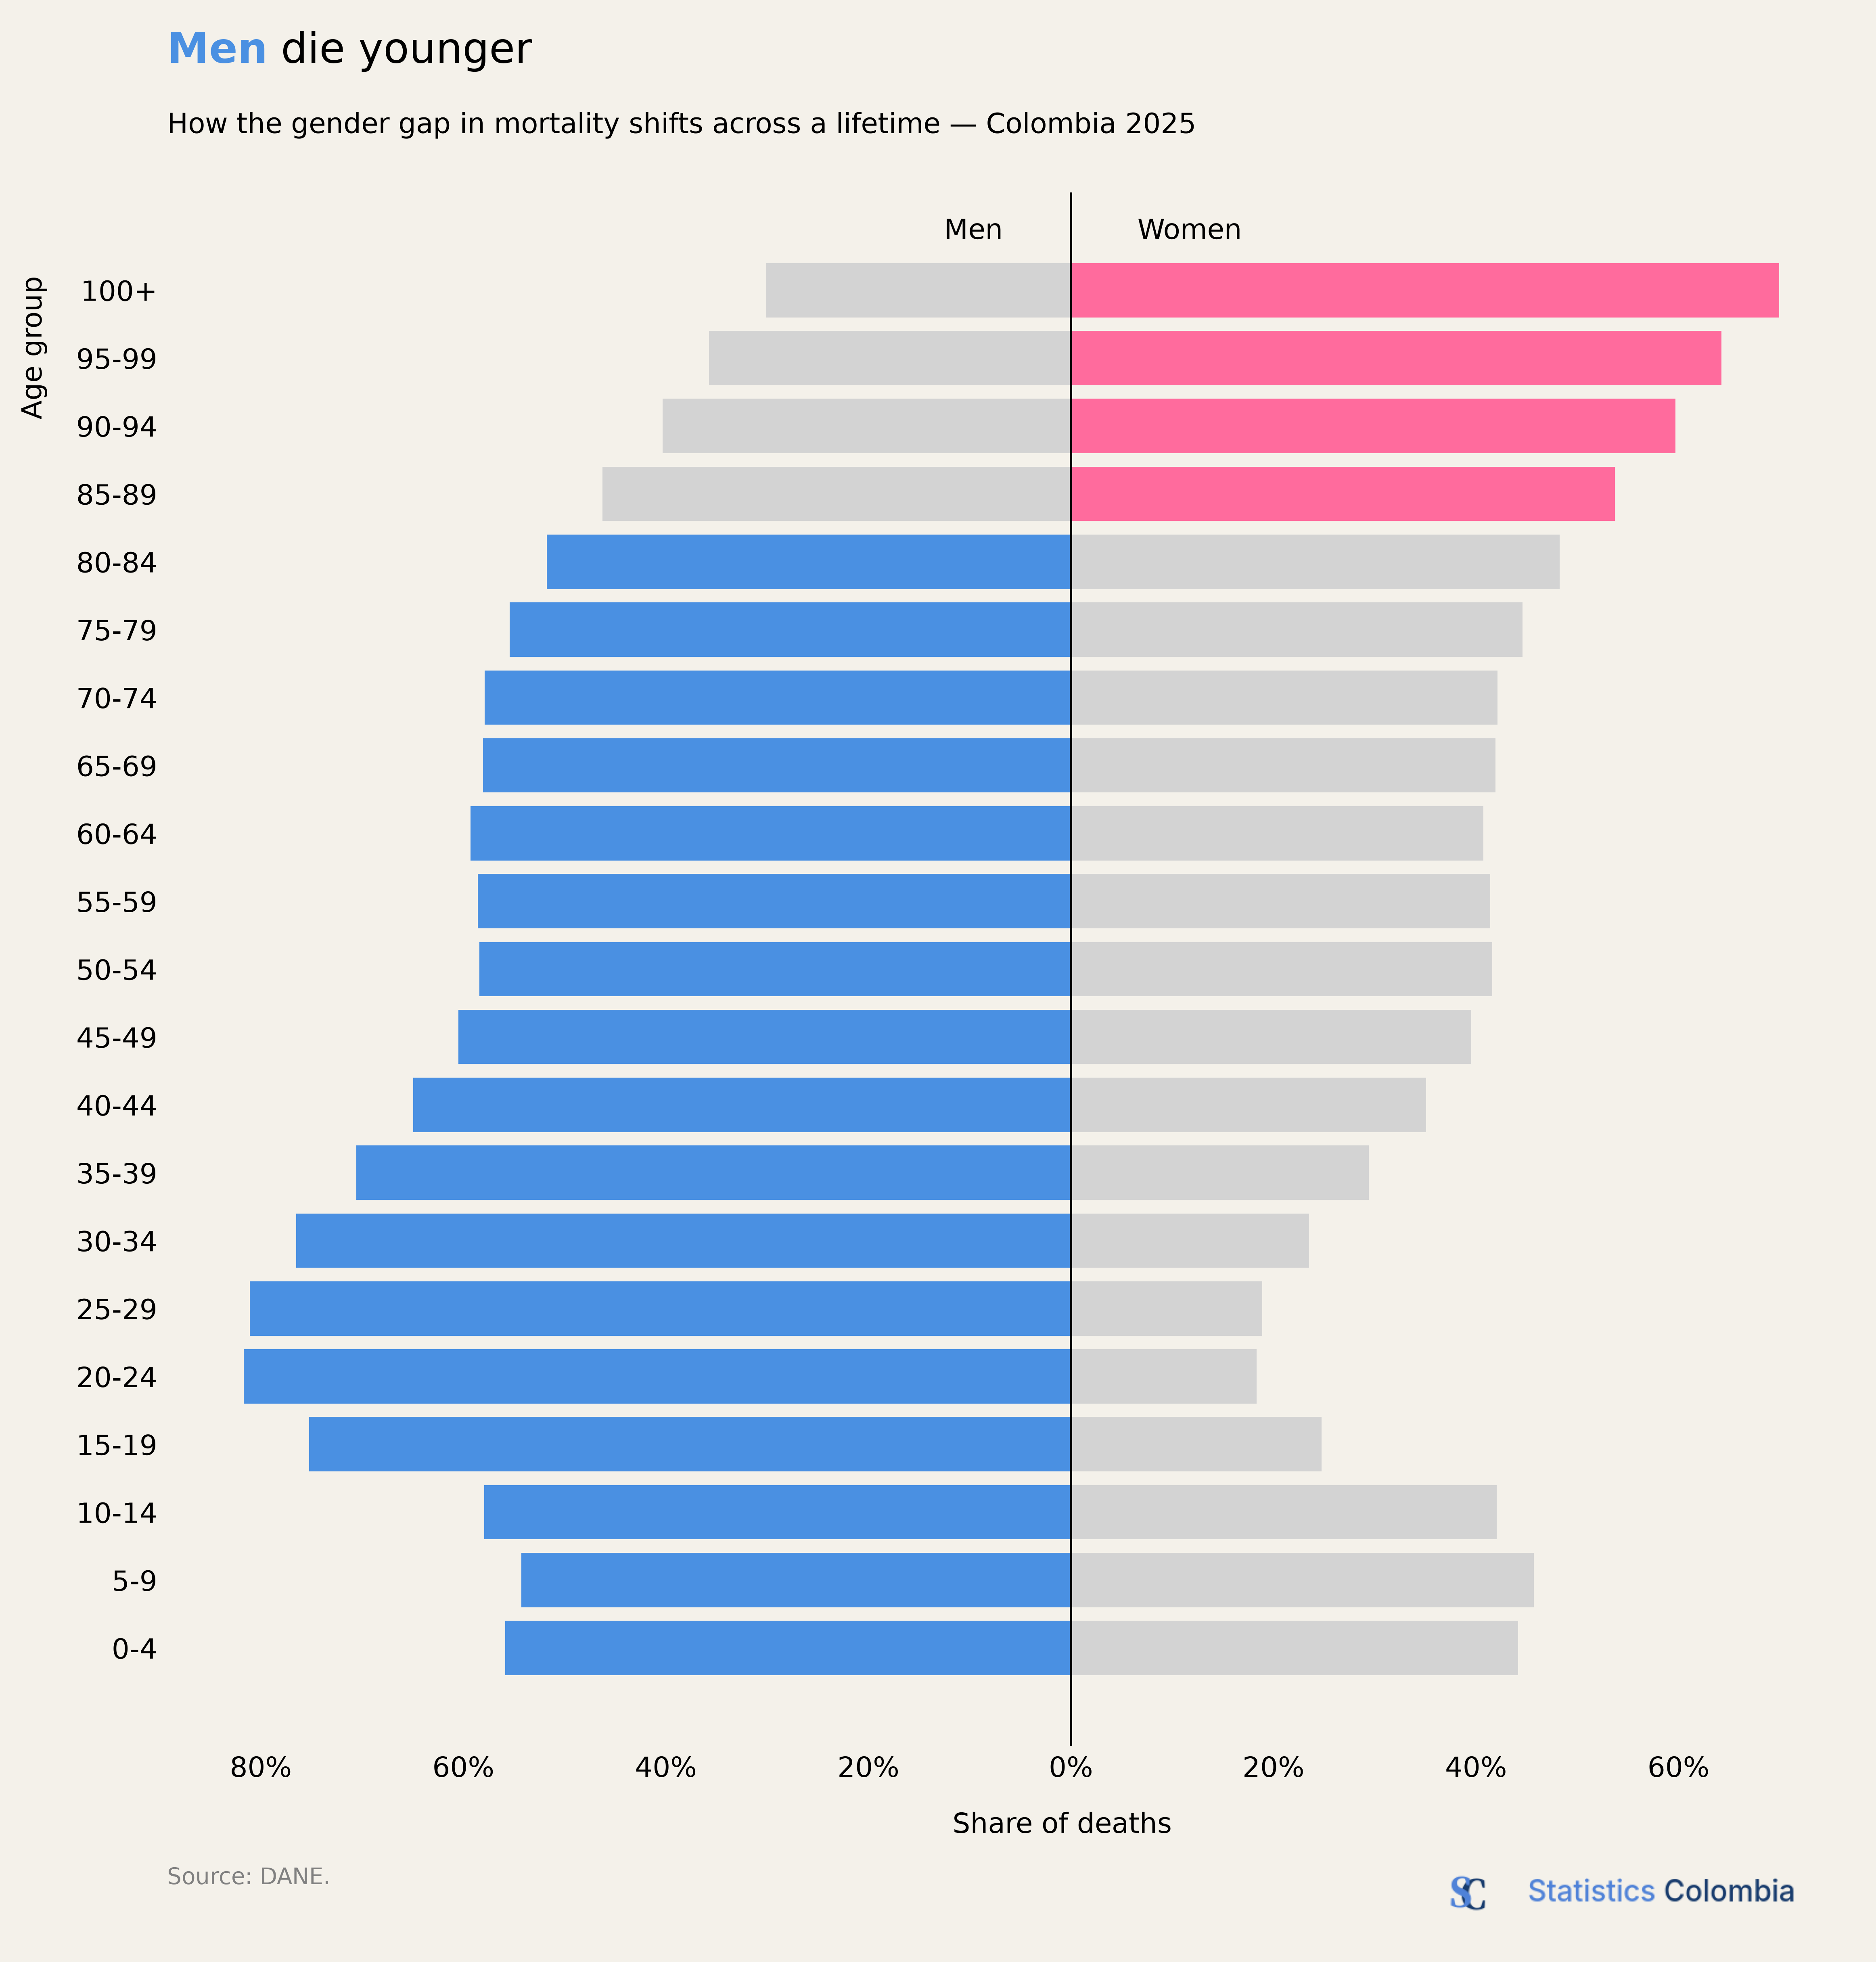

In [46]:
class HiddenHandler(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        p = Rectangle((0, 0), 0, 0, alpha=0)
        return [p]

ages = share.index
male_color = "#4A90E2"
female_color = "#FF6B9D"
gray = "#D3D3D3"

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor("#F4F1EA")
ax.patch.set_facecolor("#F4F1EA")

plt.barh(ages, [-x for x in share["Hombres"]], color=[male_color if x > 50 else gray for x in share["Hombres"]])
plt.barh(ages, share["Mujeres"], color=[female_color if x > 50 else gray for x in share["Mujeres"]])

plt.axvline(x=0, color="black", linewidth=0.8)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Age group", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Share of deaths", labelpad=10, fontsize=10, x=0.53)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.0f}%"))

fig_text(
    0.125, 0.96,
    s="<Men> die younger",
    highlight_textprops=[{"color": male_color, "weight": "bold"}],
    fontsize=15,
)

fig_text(
    0.125, 0.92,
    s="How the gender gap in mortality shifts across a lifetime — Colombia 2025",
    fontsize=10,
)

fig_text(
    0.125, 0.05, 
    "Source: DANE.\n",
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

handles = [Patch(color=male_color, label="Men"), Patch(color=female_color, label="Women")]
plt.legend(
    handles=handles,
    handler_map={Patch: HiddenHandler()},
    frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.525, 1.0)
)

plt.show()